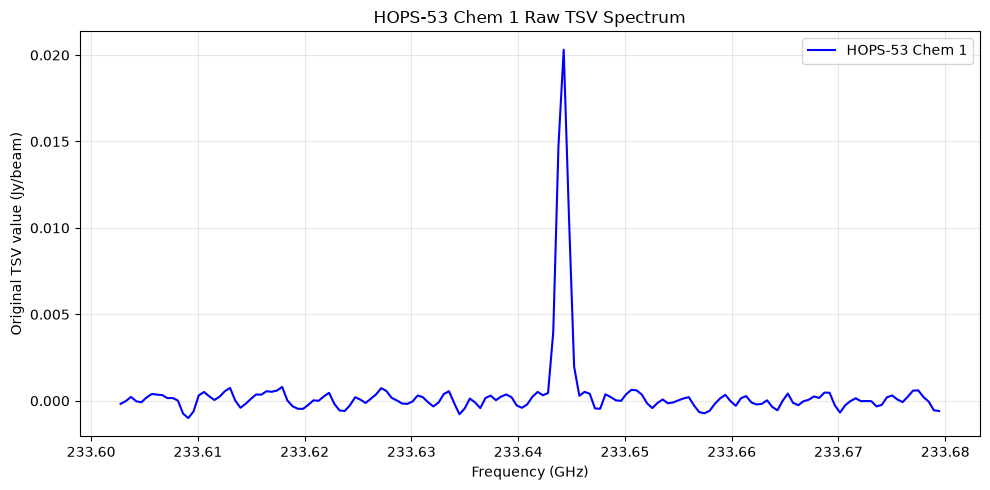

Loaded: HOPS-53 Chem 1
Finite channels: 158


In [1]:
# Load a CARTA TSV spectrum and prepare both slider fitters

# Path manages the Windows filename, Matplotlib draws the spectrum, NumPy handles
# numeric arrays, and pyspeckit performs the Gaussian spectral-line fit.
from pathlib import Path
import matplotlib.pyplot as plt
#from cube_properties import plot_zprofile_tsv
import numpy as np
import pyspeckit

# ------------------------- USER INPUTS -------------------------
# Change this path and source label when fitting another CARTA TSV export.
tsv_path = Path(r"C:\Users\aliza\Downloads\spectral analysis\tsv_files\HOPS-53_feather_Chem_1.average.tsv")
source_label = "HOPS-53 Chem 1"
tsv_skiprows = 6

# Beam and rest-frequency metadata must match the file/transition being analyzed.
beam_major_arcsec = 1.0836
beam_minor_arcsec = 0.868048
rest_frequency_ghz = 232.9800000000

# Gaussian starting guesses. Amplitude guesses are physical intensity values; leave
# either as None to initialize it automatically from the strongest spectral channel.
velocity_amplitude_guess = None
velocity_center_guess_kms = -855.0
velocity_sigma_guess_kms = 0.64

frequency_amplitude_guess = None
frequency_center_guess_ghz = 232.64418
frequency_sigma_guess_ghz = 0.011
# ---------------------------------------------------------------

#upload the tsv file
# CARTA writes six metadata rows before the tab-separated numeric data. unpack=True
# returns the first column as frequency and the second as the measured spectrum.
if not tsv_path.exists():
    raise FileNotFoundError(f"TSV file not found: {tsv_path}")

# Load two numeric columns after the configured metadata rows.
frequency, values = np.loadtxt(
    tsv_path, delimiter="\t", skiprows=tsv_skiprows, unpack=True
)
if np.ndim(frequency) != 1 or np.ndim(values) != 1 or frequency.size != values.size:
    raise ValueError("The TSV must contain two aligned numeric columns: frequency and value.")

# Plot the untouched TSV columns before any conversion or fitting.
plt.figure(figsize=(10, 5))
plt.plot(frequency, values, color='blue', label=source_label)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Original TSV value (Jy/beam)')
plt.title(f'{source_label} Raw TSV Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Prepare the physical intensity, frequency, and velocity arrays required by both sliders.
beam_major_rad = beam_major_arcsec * (np.pi / 648000)
beam_minor_rad = beam_minor_arcsec * (np.pi / 648000)
omega_beam = np.pi * beam_major_rad * beam_minor_rad / (4 * np.log(2))
intensity_jy = np.asarray(np.ma.filled(values, np.nan), dtype=float) * omega_beam
frequency_ghz = np.asarray(np.ma.filled(frequency, np.nan), dtype=float)
c_kms = 299792.458
velocity_kms = c_kms * (rest_frequency_ghz - frequency_ghz) / rest_frequency_ghz
valid = np.isfinite(frequency_ghz) & np.isfinite(velocity_kms) & np.isfinite(intensity_jy)
frequency_ghz = frequency_ghz[valid]
velocity_kms = velocity_kms[valid]
intensity_jy = intensity_jy[valid]
if frequency_ghz.size < 10:
    raise ValueError('At least 10 finite spectral channels are required for slider fitting.')
print('Loaded:', source_label)
print('Finite channels:', frequency_ghz.size)


In [2]:
# Interactive velocity-domain starting guesses. Move the sliders, then click
# the button to rerun the Gaussian fit and redraw the model and residual.
import numpy as np
import matplotlib.pyplot as plt
import pyspeckit
import ipywidgets as widgets
from astropy.io import fits
from IPython.display import display

# Build all slider defaults from the current arrays so this cell works with
# any loaded spectrum and does not depend on source-specific fit guesses.
velocity_channel_width = float(np.median(np.abs(np.diff(velocity_kms))))
velocity_span = float(np.ptp(velocity_kms))
slider_edge_count = max(1, min(intensity_jy.size // 5, 50))
slider_baseline = float(np.median(np.concatenate((
    intensity_jy[:slider_edge_count], intensity_jy[-slider_edge_count:]
))))
slider_physical_data = intensity_jy - slider_baseline
slider_peak_index = int(np.argmax(np.abs(slider_physical_data)))
slider_peak_physical = float(slider_physical_data[slider_peak_index])
slider_signal_peak = abs(slider_peak_physical)
if not np.isfinite(slider_signal_peak) or slider_signal_peak == 0:
    raise ValueError('The current file has no finite, non-zero spectral feature.')
slider_fit_scale = 1.0 / slider_signal_peak
velocity_fit_data = slider_physical_data * slider_fit_scale
automatic_slider_amplitude = slider_peak_physical * slider_fit_scale
automatic_slider_center = float(velocity_kms[slider_peak_index])

# Estimate sigma from the contiguous half-maximum width around this file's
# strongest emission or absorption feature.
slider_signed_profile = np.sign(slider_peak_physical) * slider_physical_data
slider_half_max = slider_signal_peak / 2.0
slider_left = slider_peak_index
slider_right = slider_peak_index
while slider_left > 0 and slider_signed_profile[slider_left - 1] >= slider_half_max:
    slider_left -= 1
while (slider_right < velocity_kms.size - 1
       and slider_signed_profile[slider_right + 1] >= slider_half_max):
    slider_right += 1
slider_fwhm_guess = (
    abs(float(velocity_kms[slider_right] - velocity_kms[slider_left]))
    if slider_right > slider_left else 2 * velocity_channel_width
)
automatic_slider_sigma = max(slider_fwhm_guess / 2.354820045, velocity_channel_width)
velocity_sigma_min = max(velocity_channel_width / 2, np.finfo(float).tiny)
velocity_sigma_max = max(velocity_span / 2, velocity_sigma_min * 10)
velocity_amplitude_limit = max(
    2 * abs(automatic_slider_amplitude), 2.0
)
velocity_amplitude_slider = widgets.FloatSlider(
    value=float(np.clip(automatic_slider_amplitude, -velocity_amplitude_limit, velocity_amplitude_limit)),
    min=-velocity_amplitude_limit, max=velocity_amplitude_limit,
    step=velocity_amplitude_limit / 200, description='Scaled amp.:',
    continuous_update=False, readout_format='.4g',
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
velocity_center_slider = widgets.FloatSlider(
    value=float(np.clip(automatic_slider_center, velocity_kms.min(), velocity_kms.max())),
    min=float(velocity_kms.min()), max=float(velocity_kms.max()),
    step=max(velocity_channel_width / 5, np.finfo(float).eps),
    description='Center km/s:', continuous_update=False, readout_format='.7g',
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
velocity_sigma_slider = widgets.FloatLogSlider(
    value=float(np.clip(automatic_slider_sigma, velocity_sigma_min, velocity_sigma_max)),
    base=10, min=np.log10(velocity_sigma_min), max=np.log10(velocity_sigma_max),
    step=0.01, description='Sigma km/s:', continuous_update=False,
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
velocity_fit_button = widgets.Button(description='Run velocity fit', button_style='primary')
velocity_slider_output = widgets.Output()

def run_velocity_slider_fit(_=None):
    with velocity_slider_output:
        velocity_slider_output.clear_output(wait=True)
        slider_guesses = [
            velocity_amplitude_slider.value, velocity_center_slider.value,
            velocity_sigma_slider.value,
        ]
        # Re-estimate line-free RMS for the currently selected center and width,
        # then apply exactly the same numerical scale to data and errors.
        slider_noise_exclusion = max(
            5 * velocity_sigma_slider.value, 3 * velocity_channel_width
        )
        slider_line_free = slider_physical_data[
            np.abs(velocity_kms - velocity_center_slider.value) > slider_noise_exclusion
        ]
        if slider_line_free.size < 10:
            print('Fit stopped: fewer than 10 line-free channels remain for this selection.')
            return
        slider_noise_center = float(np.median(slider_line_free))
        slider_physical_rms = 1.4826 * float(
            np.median(np.abs(slider_line_free - slider_noise_center))
        )
        if not np.isfinite(slider_physical_rms) or slider_physical_rms <= 0:
            slider_physical_rms = float(np.std(slider_line_free, ddof=1))
        if not np.isfinite(slider_physical_rms) or slider_physical_rms <= 0:
            print('Fit stopped: this file has no measurable finite off-line RMS.')
            return
        velocity_fit_error = np.full_like(
            velocity_fit_data, slider_physical_rms * slider_fit_scale
        )
        slider_spectrum = pyspeckit.Spectrum(
            data=velocity_fit_data, error=velocity_fit_error,
            xarr=velocity_kms, xarrkwargs={'unit': 'km/s'},
            unit='Jy', header=fits.Header(),
        )
        try:
            slider_spectrum.specfit(
                fittype='gaussian', guesses=slider_guesses, renormalize=True,
                limited=[(False, False), (True, True), (True, True)],
                limits=[(0, 0), (float(velocity_kms.min()), float(velocity_kms.max())),
                        (velocity_sigma_min, velocity_sigma_max)],
            )
        except Exception as exc:
            print(f'Fit failed: {exc}')
            return
        fitted = np.asarray(slider_spectrum.specfit.modelpars, dtype=float)
        raw_slider_errors = slider_spectrum.specfit.modelerrs
        if raw_slider_errors is None or len(raw_slider_errors) < 3:
            fitted_errors = np.full(3, np.nan)
        else:
            fitted_errors = np.asarray([
                np.nan if error is None else float(error)
                for error in raw_slider_errors[:3]
            ])
        guess_model = slider_guesses[0] * np.exp(
            -0.5 * ((velocity_kms - slider_guesses[1]) / slider_guesses[2]) ** 2
        )
        fitted_model = slider_spectrum.specfit.fullmodel
        residual = velocity_fit_data - fitted_model
        fig, (ax_fit, ax_residual) = plt.subplots(
            2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
        )
        ax_fit.plot(velocity_kms, velocity_fit_data / slider_fit_scale, color='blue', label=source_label)
        ax_fit.plot(velocity_kms, guess_model / slider_fit_scale, '--', color='orange', label='Input guess')
        ax_fit.plot(velocity_kms, fitted_model / slider_fit_scale, color='red', label='Gaussian fit')
        ax_fit.set_ylabel('Intensity (Jy/sr)')
        ax_fit.set_title(f'{source_label} Velocity Gaussian Fit')
        ax_fit.legend()
        ax_residual.plot(velocity_kms, residual / slider_fit_scale, color='gray', marker='.')
        ax_residual.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_residual.set_xlabel('Velocity (km/s)')
        ax_residual.set_ylabel('Residual')
        plt.tight_layout()
        plt.show()
        amplitude_physical = fitted[0] / slider_fit_scale
        amplitude_error = fitted_errors[0] / slider_fit_scale
        center = fitted[1]
        center_error = fitted_errors[1]
        sigma = abs(fitted[2])
        sigma_error = abs(fitted_errors[2])
        fwhm_factor = 2 * np.sqrt(2 * np.log(2))
        fwhm = fwhm_factor * sigma
        fwhm_error = fwhm_factor * sigma_error
        integrated = amplitude_physical * sigma * np.sqrt(2 * np.pi)
        integrated_error = np.sqrt(2 * np.pi) * np.sqrt(
            (sigma * amplitude_error) ** 2
            + (amplitude_physical * sigma_error) ** 2
        )
        # Sigma must be finite and non-zero before calculating a percentage.
        # FWHM has the same fractional uncertainty because both its value and
        # its error are sigma multiplied by the same constant (2.355).
        if np.isfinite(sigma) and sigma > 0 and np.isfinite(sigma_error):
            width_relative_error = 100.0 * sigma_error / sigma
            if width_relative_error < 10:
                width_quality = 'well constrained'
            elif width_relative_error < 30:
                width_quality = 'usable but uncertain'
            elif width_relative_error < 50:
                width_quality = 'poorly constrained'
            else:
                width_quality = 'unreliable; inspect the fit and residuals'
        else:
            width_relative_error = np.nan
            width_quality = 'unavailable because specfit did not return a valid width error'

        # Measure width from every plotted channel within +/-3 fitted sigma
        # of the center. For a Gaussian this interval contains about 99.7%
        # of the modeled line area. Positive baseline-subtracted intensities
        # provide the weights for the graph-based moment calculation.
        edge_count = max(1, min(velocity_fit_data.size // 5, 50))
        graph_baseline = float(np.median(np.concatenate((
            velocity_fit_data[:edge_count], velocity_fit_data[-edge_count:]
        ))))
        line_sign = 1.0 if amplitude_physical >= 0 else -1.0
        graph_profile = line_sign * (velocity_fit_data - graph_baseline)
        graph_sigma = np.nan
        graph_fwhm = np.nan
        graph_points_used = 0
        graph_window_mask = np.abs(velocity_kms - center) <= 3 * sigma
        graph_channels_in_window = int(np.count_nonzero(graph_window_mask))
        if graph_channels_in_window >= 2:
            graph_velocity_window = velocity_kms[graph_window_mask]
            graph_weights = np.clip(graph_profile[graph_window_mask], 0, None)
            positive = graph_weights > 0
            graph_points_used = int(np.count_nonzero(positive))
            if graph_points_used >= 2 and np.sum(graph_weights) > 0:
                graph_center = np.sum(graph_weights * graph_velocity_window) / np.sum(graph_weights)
                graph_variance = np.sum(
                    graph_weights * (graph_velocity_window - graph_center) ** 2
                ) / np.sum(graph_weights)
                graph_sigma = float(np.sqrt(max(graph_variance, 0)))
                graph_fwhm = fwhm_factor * graph_sigma
        graph_fwhm_error = velocity_channel_width
        graph_sigma_error = velocity_channel_width / fwhm_factor
        print('Slider fit scale:', slider_fit_scale)
        print('Off-line RMS:', slider_physical_rms, 'Jy/sr')
        print('Input guesses [scaled amplitude, center, sigma]:', slider_guesses)
        print('Specfit parameter errors (1 sigma)')
        print('  Amplitude:', amplitude_physical, '+/-', amplitude_error, 'Jy/sr')
        print('  Center:', center, '+/-', center_error, 'km/s')
        print('  Sigma:', sigma, '+/-', sigma_error, 'km/s')
        print('  FWHM:', fwhm, '+/-', fwhm_error, 'km/s')
        print('  Integrated intensity:', integrated, '+/-', integrated_error,
              'Jy/sr km/s')
        print('  Sigma relative error:', width_relative_error, '%')
        print('  FWHM relative error:', width_relative_error, '%')
        print('  Width assessment:', width_quality)
        excel_headers = [
            'Amplitude', 'Amplitude err', 'Center', 'Center err',
            'Sigma', 'Sigma err', 'FWHM', 'FWHM err',
            'Integrated intensity', 'Integrated intensity err',
        ]
        excel_values = [
            amplitude_physical, amplitude_error, center, center_error,
            sigma, sigma_error, fwhm, fwhm_error, integrated, integrated_error,
        ]
        print('\nExcel-ready tab-separated results (copy both lines):')
        print('\t'.join(excel_headers))
        print('\t'.join(f'{value:.10E}' for value in excel_values))
        print('Direct graph measurement using channels within +/-3 fitted sigma')
        print('  Channels inside the width window:', graph_channels_in_window)
        print('  Positive line points used:', graph_points_used)
        print('  Sigma:', graph_sigma, '+/-', graph_sigma_error, 'km/s')
        print('  FWHM:', graph_fwhm, '+/-', graph_fwhm_error, 'km/s')
        print('  (These errors represent one-channel graph resolution, not specfit covariance.)')
        if not np.isfinite(graph_fwhm):
            print('  Direct width unavailable: fewer than two usable line points were found.')
        if np.any(~np.isfinite(fitted_errors)):
            print('Note: specfit did not return a complete covariance-based error estimate.')

velocity_fit_button.on_click(run_velocity_slider_fit)
display(widgets.VBox([
    widgets.HTML('<b>Velocity Gaussian starting guesses</b>'),
    velocity_amplitude_slider, velocity_center_slider, velocity_sigma_slider,
    velocity_fit_button, velocity_slider_output,
]))
run_velocity_slider_fit()


In [3]:
# Interactive frequency-domain starting guesses. Move the sliders, then click
# the button to rerun the Gaussian fit and redraw the model and residual.
import numpy as np
import matplotlib.pyplot as plt
import pyspeckit
import ipywidgets as widgets
from astropy.io import fits
from IPython.display import display

# Build all slider defaults from the current arrays so this cell works with
# any loaded spectrum and does not depend on source-specific fit guesses.
frequency_channel_width = float(np.median(np.abs(np.diff(frequency_ghz))))
frequency_span = float(np.ptp(frequency_ghz))
slider_edge_count = max(1, min(intensity_jy.size // 5, 50))
slider_baseline = float(np.median(np.concatenate((
    intensity_jy[:slider_edge_count], intensity_jy[-slider_edge_count:]
))))
slider_physical_data = intensity_jy - slider_baseline
slider_peak_index = int(np.argmax(np.abs(slider_physical_data)))
slider_peak_physical = float(slider_physical_data[slider_peak_index])
slider_signal_peak = abs(slider_peak_physical)
if not np.isfinite(slider_signal_peak) or slider_signal_peak == 0:
    raise ValueError('The current file has no finite, non-zero spectral feature.')
slider_fit_scale = 1.0 / slider_signal_peak
frequency_fit_data = slider_physical_data * slider_fit_scale
automatic_slider_amplitude = slider_peak_physical * slider_fit_scale
automatic_slider_center = float(frequency_ghz[slider_peak_index])

# Estimate sigma from the contiguous half-maximum width around this file's
# strongest emission or absorption feature.
slider_signed_profile = np.sign(slider_peak_physical) * slider_physical_data
slider_half_max = slider_signal_peak / 2.0
slider_left = slider_peak_index
slider_right = slider_peak_index
while slider_left > 0 and slider_signed_profile[slider_left - 1] >= slider_half_max:
    slider_left -= 1
while (slider_right < frequency_ghz.size - 1
       and slider_signed_profile[slider_right + 1] >= slider_half_max):
    slider_right += 1
slider_fwhm_guess = (
    abs(float(frequency_ghz[slider_right] - frequency_ghz[slider_left]))
    if slider_right > slider_left else 2 * frequency_channel_width
)
automatic_slider_sigma = max(slider_fwhm_guess / 2.354820045, frequency_channel_width)
frequency_sigma_min = max(frequency_channel_width / 2, np.finfo(float).tiny)
frequency_sigma_max = max(frequency_span / 2, frequency_sigma_min * 10)
frequency_amplitude_limit = max(
    2 * abs(automatic_slider_amplitude), 2.0
)
frequency_amplitude_slider = widgets.FloatSlider(
    value=float(np.clip(automatic_slider_amplitude, -frequency_amplitude_limit, frequency_amplitude_limit)),
    min=-frequency_amplitude_limit, max=frequency_amplitude_limit,
    step=frequency_amplitude_limit / 200, description='Scaled amp.:',
    continuous_update=False, readout_format='.4g',
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
frequency_center_slider = widgets.FloatSlider(
    value=float(np.clip(automatic_slider_center, frequency_ghz.min(), frequency_ghz.max())),
    min=float(frequency_ghz.min()), max=float(frequency_ghz.max()),
    step=max(frequency_channel_width / 5, np.finfo(float).eps),
    description='Center GHz:', continuous_update=False, readout_format='.7g',
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
frequency_sigma_slider = widgets.FloatLogSlider(
    value=float(np.clip(automatic_slider_sigma, frequency_sigma_min, frequency_sigma_max)),
    base=10, min=np.log10(frequency_sigma_min), max=np.log10(frequency_sigma_max),
    step=0.01, description='Sigma GHz:', continuous_update=False,
    layout=widgets.Layout(width='95%'), style={'description_width': '90px'},
)
frequency_fit_button = widgets.Button(description='Run frequency fit', button_style='primary')
frequency_slider_output = widgets.Output()

def run_frequency_slider_fit(_=None):
    with frequency_slider_output:
        frequency_slider_output.clear_output(wait=True)
        slider_guesses = [
            frequency_amplitude_slider.value, frequency_center_slider.value,
            frequency_sigma_slider.value,
        ]
        # Re-estimate line-free RMS for the currently selected center and width,
        # then apply exactly the same numerical scale to data and errors.
        slider_noise_exclusion = max(
            5 * frequency_sigma_slider.value, 3 * frequency_channel_width
        )
        slider_line_free = slider_physical_data[
            np.abs(frequency_ghz - frequency_center_slider.value) > slider_noise_exclusion
        ]
        if slider_line_free.size < 10:
            print('Fit stopped: fewer than 10 line-free channels remain for this selection.')
            return
        slider_noise_center = float(np.median(slider_line_free))
        slider_physical_rms = 1.4826 * float(
            np.median(np.abs(slider_line_free - slider_noise_center))
        )
        if not np.isfinite(slider_physical_rms) or slider_physical_rms <= 0:
            slider_physical_rms = float(np.std(slider_line_free, ddof=1))
        if not np.isfinite(slider_physical_rms) or slider_physical_rms <= 0:
            print('Fit stopped: this file has no measurable finite off-line RMS.')
            return
        frequency_fit_error = np.full_like(
            frequency_fit_data, slider_physical_rms * slider_fit_scale
        )
        # Keep the optimizer on the peak selected by the sliders. Searching the
        # entire band can let a narrow Gaussian jump to an unrelated noise channel.
        center_half_width = max(
            2 * frequency_sigma_slider.value, 2 * frequency_channel_width
        )
        center_lower = max(
            float(frequency_ghz.min()), frequency_center_slider.value - center_half_width
        )
        center_upper = min(
            float(frequency_ghz.max()), frequency_center_slider.value + center_half_width
        )
        if frequency_amplitude_slider.value >= 0:
            amplitude_limits = (0.0, 5 * frequency_amplitude_limit)
        else:
            amplitude_limits = (-5 * frequency_amplitude_limit, 0.0)
        fit_window_half_width = max(
            6 * frequency_sigma_slider.value, 6 * frequency_channel_width
        )
        frequency_local_mask = (
            np.abs(frequency_ghz - frequency_center_slider.value) <= fit_window_half_width
        )
        if np.count_nonzero(frequency_local_mask) < 7:
            print('Fit stopped: fewer than 7 channels surround the selected peak.')
            return
        local_frequency = frequency_ghz[frequency_local_mask]
        local_fit_data = frequency_fit_data[frequency_local_mask]
        local_fit_error = frequency_fit_error[frequency_local_mask]
        slider_spectrum = pyspeckit.Spectrum(
            data=local_fit_data, error=local_fit_error,
            xarr=local_frequency, xarrkwargs={'unit': 'GHz'},
            unit='Jy', header=fits.Header(),
        )
        try:
            slider_spectrum.specfit(
                fittype='gaussian', guesses=slider_guesses, renormalize=True,
                limited=[(True, True), (True, True), (True, True)],
                limits=[amplitude_limits, (center_lower, center_upper),
                        (frequency_sigma_min, frequency_sigma_max)],
            )
        except Exception as exc:
            print(f'Fit failed: {exc}')
            return
        fitted = np.asarray(slider_spectrum.specfit.modelpars, dtype=float)
        raw_slider_errors = slider_spectrum.specfit.modelerrs
        if raw_slider_errors is None or len(raw_slider_errors) < 3:
            fitted_errors = np.full(3, np.nan)
        else:
            fitted_errors = np.asarray([
                np.nan if error is None else float(error)
                for error in raw_slider_errors[:3]
            ])
        guess_model = slider_guesses[0] * np.exp(
            -0.5 * ((frequency_ghz - slider_guesses[1]) / slider_guesses[2]) ** 2
        )
        # Draw the fitted local solution over the complete displayed frequency axis.
        fitted_model = fitted[0] * np.exp(
            -0.5 * ((frequency_ghz - fitted[1]) / fitted[2]) ** 2
        )
        residual = frequency_fit_data - fitted_model
        fig, (ax_fit, ax_residual) = plt.subplots(
            2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]}
        )
        ax_fit.plot(frequency_ghz, frequency_fit_data / slider_fit_scale, color='blue', label=source_label)
        ax_fit.plot(frequency_ghz, guess_model / slider_fit_scale, '--', color='orange', label='Input guess')
        ax_fit.plot(frequency_ghz, fitted_model / slider_fit_scale, color='red', label='Gaussian fit')
        ax_fit.set_ylabel('Intensity (Jy/sr)')
        ax_fit.set_title(f'{source_label} Frequency Gaussian Fit')
        ax_fit.legend()
        ax_residual.plot(frequency_ghz, residual / slider_fit_scale, color='gray', marker='.')
        ax_residual.axhline(0, color='black', linestyle='--', linewidth=1)
        ax_residual.set_xlabel('Frequency (GHz)')
        ax_residual.set_ylabel('Residual')
        plt.tight_layout()
        plt.show()
        amplitude_physical = fitted[0] / slider_fit_scale
        amplitude_error = fitted_errors[0] / slider_fit_scale
        center = fitted[1]
        center_error = fitted_errors[1]
        sigma = abs(fitted[2])
        sigma_error = abs(fitted_errors[2])
        fwhm_factor = 2 * np.sqrt(2 * np.log(2))
        fwhm = fwhm_factor * sigma
        fwhm_error = fwhm_factor * sigma_error
        integrated = amplitude_physical * sigma * np.sqrt(2 * np.pi)
        integrated_error = np.sqrt(2 * np.pi) * np.sqrt(
            (sigma * amplitude_error) ** 2
            + (amplitude_physical * sigma_error) ** 2
        )
        # Sigma must be finite and non-zero before calculating a percentage.
        # FWHM has the same fractional uncertainty because both its value and
        # its error are sigma multiplied by the same constant (2.355).
        if np.isfinite(sigma) and sigma > 0 and np.isfinite(sigma_error):
            width_relative_error = 100.0 * sigma_error / sigma
            if width_relative_error < 10:
                width_quality = 'well constrained'
            elif width_relative_error < 30:
                width_quality = 'usable but uncertain'
            elif width_relative_error < 50:
                width_quality = 'poorly constrained'
            else:
                width_quality = 'unreliable; inspect the fit and residuals'
        else:
            width_relative_error = np.nan
            width_quality = 'unavailable because specfit did not return a valid width error'

        # Measure width from every plotted channel within +/-3 fitted sigma
        # of the center. For a Gaussian this interval contains about 99.7%
        # of the modeled line area. Positive baseline-subtracted intensities
        # provide the weights for the graph-based moment calculation.
        edge_count = max(1, min(frequency_fit_data.size // 5, 50))
        graph_baseline = float(np.median(np.concatenate((
            frequency_fit_data[:edge_count], frequency_fit_data[-edge_count:]
        ))))
        line_sign = 1.0 if amplitude_physical >= 0 else -1.0
        graph_profile = line_sign * (frequency_fit_data - graph_baseline)
        graph_sigma = np.nan
        graph_fwhm = np.nan
        graph_points_used = 0
        graph_window_mask = np.abs(frequency_ghz - center) <= 3 * sigma
        graph_channels_in_window = int(np.count_nonzero(graph_window_mask))
        if graph_channels_in_window >= 2:
            graph_frequency_window = frequency_ghz[graph_window_mask]
            graph_weights = np.clip(graph_profile[graph_window_mask], 0, None)
            positive = graph_weights > 0
            graph_points_used = int(np.count_nonzero(positive))
            if graph_points_used >= 2 and np.sum(graph_weights) > 0:
                graph_center = np.sum(graph_weights * graph_frequency_window) / np.sum(graph_weights)
                graph_variance = np.sum(
                    graph_weights * (graph_frequency_window - graph_center) ** 2
                ) / np.sum(graph_weights)
                graph_sigma = float(np.sqrt(max(graph_variance, 0)))
                graph_fwhm = fwhm_factor * graph_sigma
        graph_fwhm_error = frequency_channel_width
        graph_sigma_error = frequency_channel_width / fwhm_factor
        print('Slider fit scale:', slider_fit_scale)
        print('Off-line RMS:', slider_physical_rms, 'Jy/sr')
        print('Input guesses [scaled amplitude, center, sigma]:', slider_guesses)
        print('Specfit parameter errors (1 sigma)')
        print('  Amplitude:', amplitude_physical, '+/-', amplitude_error, 'Jy/sr')
        print('  Center:', center, '+/-', center_error, 'GHz')
        print('  Sigma:', sigma, '+/-', sigma_error, 'GHz')
        print('  FWHM:', fwhm, '+/-', fwhm_error, 'GHz')
        print('  Integrated intensity:', integrated, '+/-', integrated_error,
              'Jy/sr GHz')
        print('  Sigma relative error:', width_relative_error, '%')
        print('  FWHM relative error:', width_relative_error, '%')
        print('  Width assessment:', width_quality)
        excel_headers = [
            'Amplitude', 'Amplitude err', 'Center', 'Center err',
            'Sigma', 'Sigma err', 'FWHM', 'FWHM err',
            'Integrated intensity', 'Integrated intensity err',
        ]
        excel_values = [
            amplitude_physical, amplitude_error, center, center_error,
            sigma, sigma_error, fwhm, fwhm_error, integrated, integrated_error,
        ]
        print('\nExcel-ready tab-separated results (copy both lines):')
        print('\t'.join(excel_headers))
        print('\t'.join(f'{value:.10E}' for value in excel_values))
        print('Direct graph measurement using channels within +/-3 fitted sigma')
        print('  Channels inside the width window:', graph_channels_in_window)
        print('  Positive line points used:', graph_points_used)
        print('  Sigma:', graph_sigma, '+/-', graph_sigma_error, 'GHz')
        print('  FWHM:', graph_fwhm, '+/-', graph_fwhm_error, 'GHz')
        print('  (These errors represent one-channel graph resolution, not specfit covariance.)')
        if not np.isfinite(graph_fwhm):
            print('  Direct width unavailable: fewer than two usable line points were found.')
        if np.any(~np.isfinite(fitted_errors)):
            print('Note: specfit did not return a complete covariance-based error estimate.')

frequency_fit_button.on_click(run_frequency_slider_fit)
display(widgets.VBox([
    widgets.HTML('<b>Frequency Gaussian starting guesses</b>'),
    frequency_amplitude_slider, frequency_center_slider, frequency_sigma_slider,
    frequency_fit_button, frequency_slider_output,
]))
run_frequency_slider_fit()
